In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score
from xgboost import XGBRegressor

In [3]:
stroke_data = pd.read_csv("stroke_data.csv")

stroke_data

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


Rozklad kolumny "age", ktora bedzie targetem w regresji.

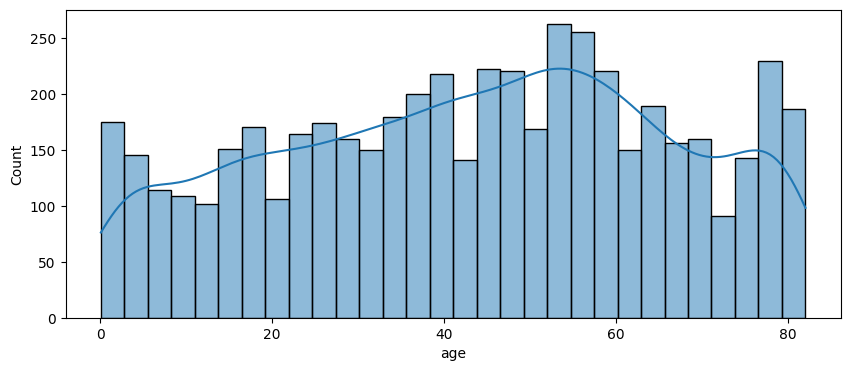

count    5110.000000
mean       43.226614
std        22.612647
min         0.080000
25%        25.000000
50%        45.000000
75%        61.000000
max        82.000000
Name: age, dtype: float64


In [4]:
plt.figure(figsize=(10 ,4))
sns.histplot(data=stroke_data["age"], bins=30, kde=True)
plt.show()

print(stroke_data["age"].describe())

Rozklad kolumny "age" nie jest zblizony do jakiegokolwiek innego znanego rozkladu co moze sugerowac ze dane uzyte do analizy sa tzw. danymi uczacymi ktore nie maja realnego pokrycia z "prawdziwymi" danymi. Mimo to histogram wyraznie pokazal ze wzrasta ilosc osob wraz ze wzrostem wieku, co przy analizie udarow mozgu jest dosc oczywistym zjawiskiem.

Sprawdzenie rowniez pozostalych kolumn w datasecie.

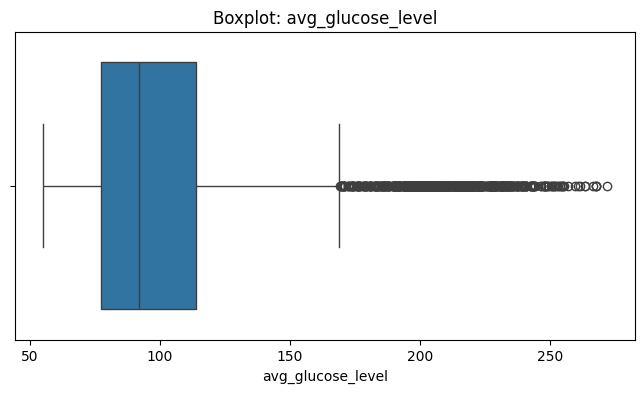

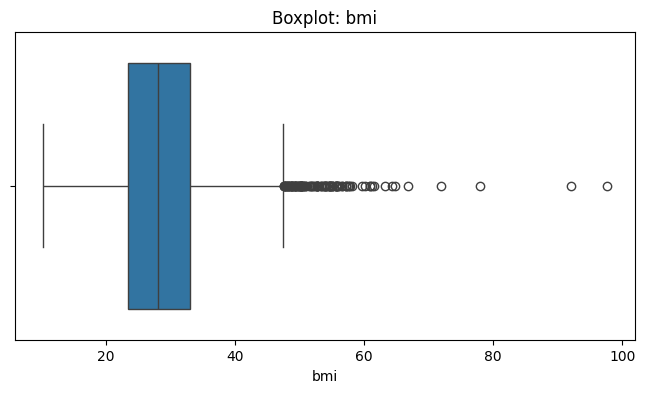

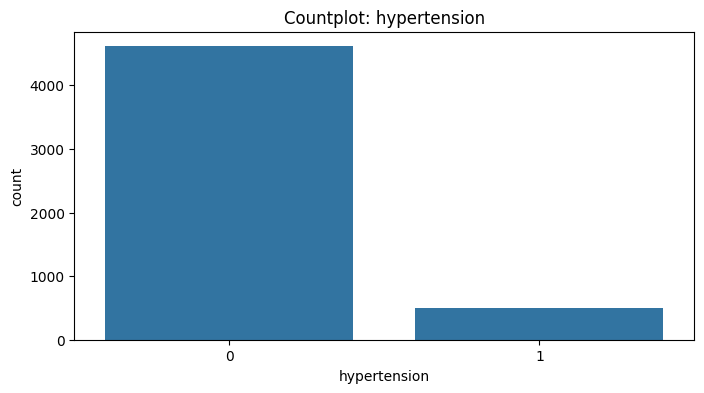

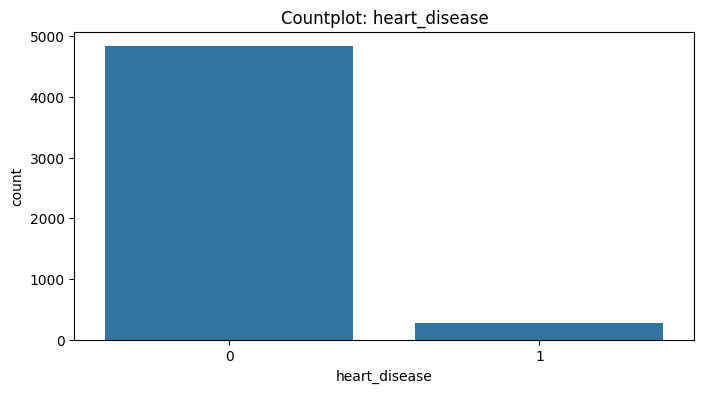

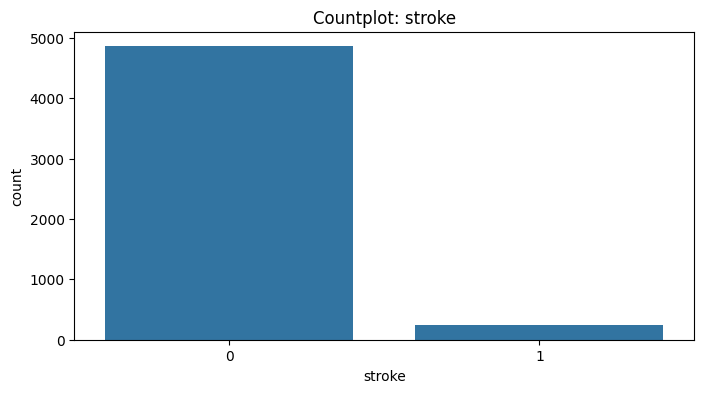

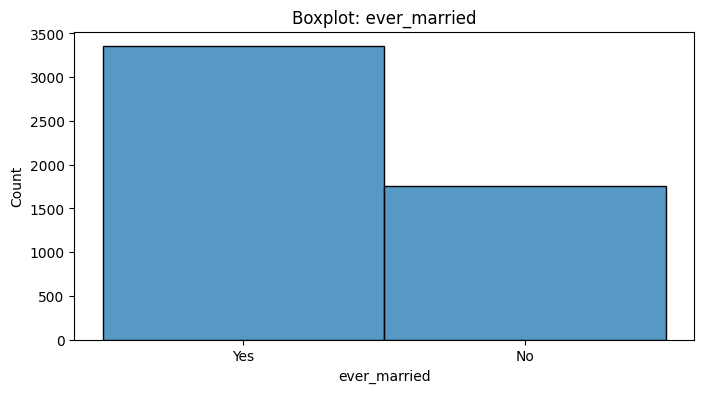

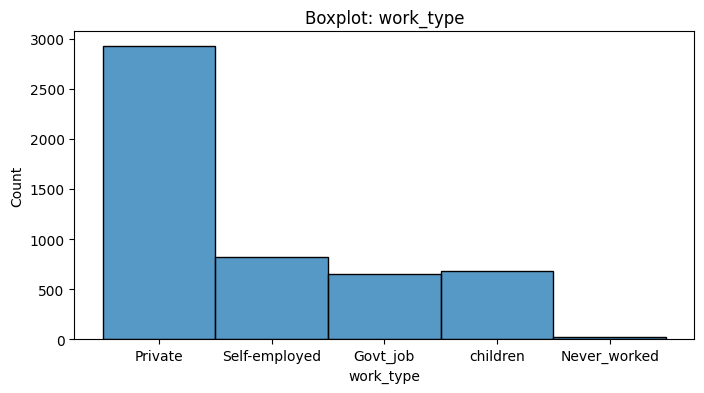

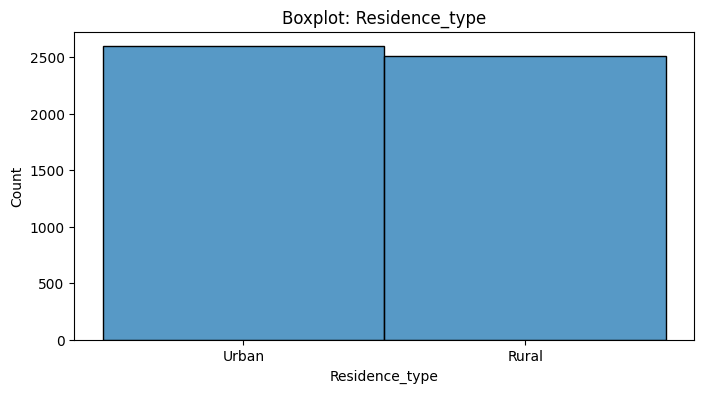

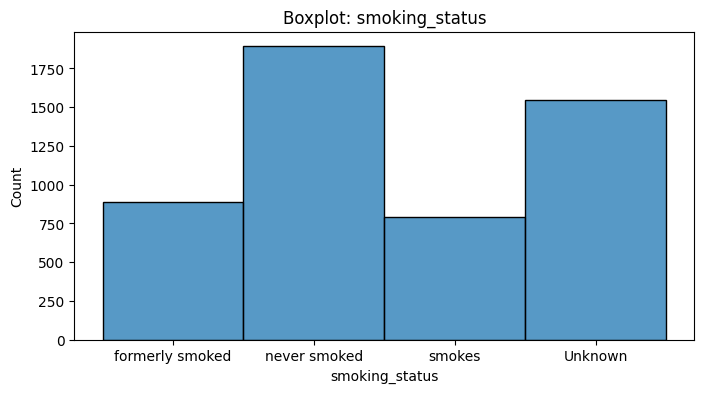

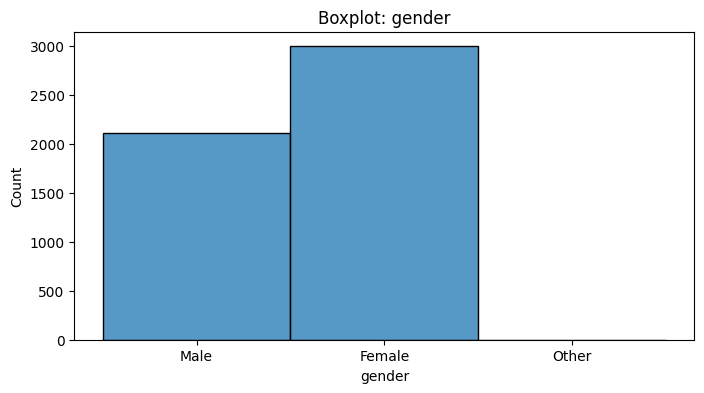

In [5]:
columns = {
    "to_box": ['avg_glucose_level', 'bmi'],
    "to_count": ['hypertension', 'heart_disease', 'stroke'],
    "to_hist":  ['ever_married', 'work_type', 'Residence_type', 'smoking_status', 'gender']
}

for direct, params in columns.items():
    if direct == "to_box":
        for col in params:
            plt.figure(figsize=(8,4))
            plt.title(f"Boxplot: {col}")
            sns.boxplot(x=stroke_data[col])
            plt.show()
    elif direct == "to_count":
        for col in params:
            plt.figure(figsize=(8,4))
            plt.title(f"Countplot: {col}")
            sns.countplot(x=stroke_data[col])
            plt.show()
    else:
        for col in params:
            plt.figure(figsize=(8,4))
            plt.title(f"Boxplot: {col}")
            sns.histplot(x=stroke_data[col])
            plt.show()

<Axes: >

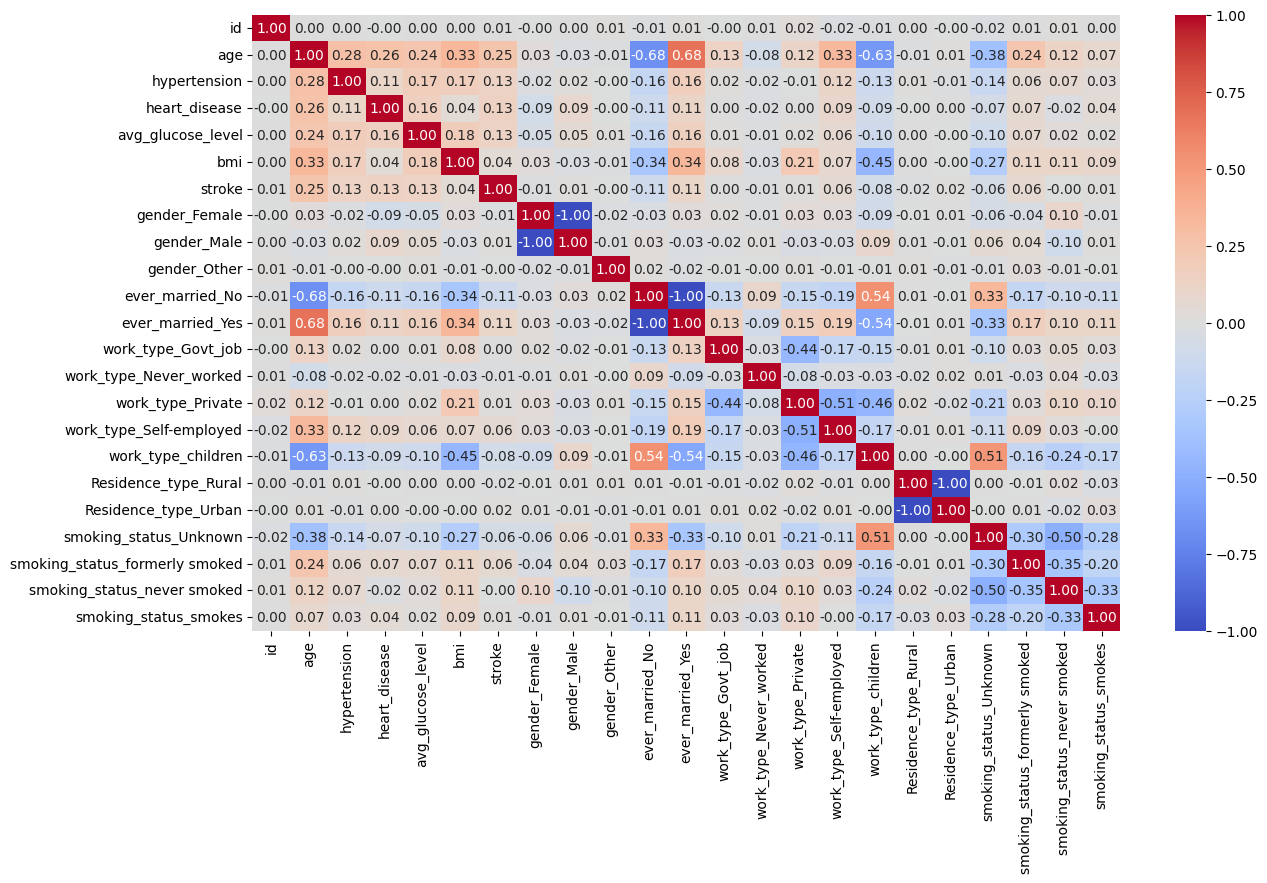

In [6]:
backup = pd.get_dummies(data=stroke_data)
corr = backup.corr()

plt.figure(figsize=(14, 8))
sns.heatmap(data=corr, annot=True, cmap='coolwarm', fmt='.2f')

Jak widac po wykresach jesli jest sie niezonatym, niepracujacym mezczyzna ktory ma bmi i glukoze w normie to ryzyko zachorowania jest znacznie nizsze niz w przypadku pracujacego ojca i meza. (zarcik)

Zmiana wzgledem poprzednich analiz (Breast_Cancer v1). Encoding musi odbywac sie na czesci danych (dane treningowe) a nie jak wczesniej na calym datasecie. Jesli nie zastosuje sie tego to moze nastapic data leakage lub "zuzycie" datasetu. Wprowadza sie rowniez ColumnTransformer ktory pelni funkcje "formy" dla encodingu danych.

In [7]:
text_cols = stroke_data.select_dtypes(include=['object']).columns

for col in text_cols:
    print(f"----{col}----")
    print(stroke_data[col].unique())

----gender----
['Male' 'Female' 'Other']
----ever_married----
['Yes' 'No']
----work_type----
['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
----Residence_type----
['Urban' 'Rural']
----smoking_status----
['formerly smoked' 'never smoked' 'smokes' 'Unknown']


In [8]:
numeric_cols = ['avg_glucose_level', 'bmi', 'hypertension', 'heart_disease']
onehot_cols = ["ever_married", "work_type"]
ordinal_col = ["smoking_status"]

# for Ridge and Lasso models
preprocessor_scaled = ColumnTransformer(transformers=[
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric_cols),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'), onehot_cols),
    ('ord_ss', OrdinalEncoder(categories=[['Unknown', 'never smoked', 'formerly smoked', 'smokes']]), [ordinal_col[0]])
])

# for XGB and Forest
preprocessor_unscaled = ColumnTransformer(transformers=[
    ('num', 'passthrough', numeric_cols),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'), onehot_cols),
    ('ord_ss', OrdinalEncoder(categories=[['Unknown', 'never smoked', 'formerly smoked', 'smokes']]), [ordinal_col[0]])    
])

In [9]:
y = stroke_data['age']
X = stroke_data[['hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'ever_married', 'work_type', 'smoking_status']]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
pipelines = {
    'Ridge': Pipeline([('preprocessor', preprocessor_scaled), ('model', Ridge(random_state=42))]),
    'Lasso': Pipeline([('preprocessor', preprocessor_scaled), ('model', Lasso(random_state=42))]),
    'RandomForest': Pipeline([('preprocessor', preprocessor_unscaled), ('model', RandomForestRegressor(random_state=42))]),
    "XGBoost": Pipeline([('preprocessor', preprocessor_unscaled), ('model', XGBRegressor(random_state=42))])
}

Po przygotowaniu calego pipelinu pora na sprawdzenie jak poradza sobie modele. <br>
Uzywa sie do tego cross_val_score aby modele na pewno nie mialy mozliwosci nauczenia sie danych ani "trafienia" odpowiedzi. <br>
Ponizej printujemy surowe wyniki R2 dla kazdej czesci danych treningowych a pozniej liczymy srednia z tych wynikow zeby miec poglad na cala sytuacje.<br>
(Printowanie kazdego jednego wyniku dla setu treningowego sluzy sprawdzaniu kazdej iteracji i tego czy ktorys z modeli przestrzelil albo niedostrzelil).

In [12]:
for name, pipeline in pipelines.items():
    scores = cross_val_score(estimator=pipeline, X=X_train, y=y_train, cv=5, scoring='r2')
    print(f"Surowe wyniki dla {name}: {scores}")
    print(f"{name}: {scores.mean():.2f} +- {scores.std():.2f}")

Surowe wyniki dla Ridge: [0.65446773 0.61731768 0.63760184 0.63315325 0.62967143]
Ridge: 0.63 +- 0.01
Surowe wyniki dla Lasso: [0.61925542 0.5838237  0.60324329 0.60248303 0.59458093]
Lasso: 0.60 +- 0.01
Surowe wyniki dla RandomForest: [0.62843076 0.5771651  0.6151975  0.59806951 0.61277265]
RandomForest: 0.61 +- 0.02
Surowe wyniki dla XGBoost: [0.60330117 0.55670365 0.58052771 0.5648767  0.58388309]
XGBoost: 0.58 +- 0.02


Najprostszy model (liniowy) poradzil sobie najlepiej, z R2 na poziomie 0.63 przy odchyleniu +- 0.01 co jest calkiem dobrym wynikiem. <br> 
Pomimo skomplikowania danych widac ze zaleznosc parametrow od wieku jest liniowa.<br>
Pora dopracowac modele za pomoca GridSearchCV.

In [13]:
# dla ridge i lasso

params_ridge_lasso = {
    'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}

grid_ridge = GridSearchCV(
    estimator=pipelines['Ridge'],
    param_grid=params_ridge_lasso,
    scoring='r2',
    cv=5,
    verbose=1
)

grid_lasso = GridSearchCV(
    estimator=pipelines['Lasso'],
    param_grid=params_ridge_lasso,
    scoring='r2',
    cv=5,
    verbose=1
)

grid_ridge.fit(X_train, y_train)
grid_ridge_best = grid_ridge.best_estimator_
print(f"{grid_ridge.__class__.__name__}: {grid_ridge.best_params_}")

grid_lasso.fit(X_train, y_train)
grid_lasso_best = grid_lasso.best_estimator_
print(f"{grid_lasso.__class__.__name__}: {grid_lasso.best_params_}")


Fitting 5 folds for each of 5 candidates, totalling 25 fits
GridSearchCV: {'model__alpha': 0.01}
Fitting 5 folds for each of 5 candidates, totalling 25 fits
GridSearchCV: {'model__alpha': 0.01}


In [14]:
# dla RandomForest

params_forest = {
    'model__max_depth': [2,3,4],
    'model__n_estimators': [50, 100, 200],
    'model__min_samples_leaf': [1,3,5,10]
}

grid_forest = GridSearchCV(
    estimator=pipelines['RandomForest'],
    param_grid=params_forest,
    scoring='r2',
    cv=5,
    verbose=1
)

grid_forest.fit(X_train, y_train)
grid_forest_best = grid_forest.best_estimator_
print(f"{grid_forest.__class__.__name__}: {grid_forest.best_params_}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
GridSearchCV: {'model__max_depth': 4, 'model__min_samples_leaf': 5, 'model__n_estimators': 50}


In [15]:
# dla XGBoost

params_xgb = {
    'model__max_depth': [2,3,4],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__n_estimators': [50, 100, 200]
}

grid_xgb = GridSearchCV(
    estimator=pipelines['XGBoost'],
    param_grid=params_xgb,
    scoring='r2',
    cv=5,
    verbose=1
)

grid_xgb.fit(X_train, y_train)
grid_xgb_best = grid_xgb.best_estimator_
print(f"{grid_xgb.__class__.__name__}: {grid_xgb.best_params_}")


Fitting 5 folds for each of 27 candidates, totalling 135 fits
GridSearchCV: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}


Po dobraniu parametrow pora na ostateczny pipeline przed wyborem modelu.

In [16]:
models = {
    'Ridge': grid_ridge_best,
    'Lasso': grid_lasso_best,
    'RandomForest': grid_forest_best,
    'XGBoost': grid_xgb_best
}

results = {}
for name, model in models.items():
    scores = cross_val_score(estimator=model, X=X_train, y=y_train, cv=5, scoring='r2')

    results[name] = scores.mean()
    print(f"{name}: {scores.mean():.2f} +- {scores.std():.2f}")

Ridge: 0.63 +- 0.01
Lasso: 0.63 +- 0.01
RandomForest: 0.64 +- 0.01
XGBoost: 0.66 +- 0.02


Przed ostatecznym wyborem modelu nalezy jeszcze porownac ich dzialanie z Dummy Regressor, modelem ktory ma za zadanie byc absolutnym baselinem i pokazywac czy wytrenowane modele rzeczywiscie znalazly zaleznosci czy po prostu "strzelily" wynik.

In [17]:
dummy_score = cross_val_score(estimator=DummyRegressor(strategy='mean'), X=X_train, y=y_train, cv=5, scoring='r2')
print(f"Dummy score: {dummy_score.mean():.3f} +- {dummy_score.std():.3f}")

Dummy score: -0.002 +- 0.001


Modele znacznie przewyzszaja wynikami DummyRegressor co oznacza ze nauczyly sie w pewnym stopniu zaleznosci a nie polegaly na zapamietywaniu wynikow.

Pora na wybor zwycieskiego modelu, nie jest to tak jednoznaczne i proste jak moze sie wydawac. <br>
Wynikowo najlepiej wypadaja XGBoost oraz RandomForest. W kontekscie medycznym jednak wybor z ktoregokolwiek z prostszych modeli (tj. Ridge i Lasso), ktorych wyniki byly rownie wysokie staje sie uzsasadnionym wyborem ze wzgledu na bardzo dobra wyjasnialnosc modelu. <br>
Przez wyjasnialnosc rozumie sie moznosc zobaczenia ktore zmienne wplynely na wynik modelu, daje to dobre podstawy do analizy i podparcia danego wyniku rzeczywista medyczna wiedza. <br>
Przez wyjasnialnosc modelu rozumie sie oczywiscie rowniez zaleznosc liniowa dla modeli Ridge i Lasso, czyli prostote wytlumaczenia ze wartosc Y wzrosla o X, modele drzewiaste nie sa "czarna skrzynka", rowniez maja swoje feature_importances_ ale nie sa to zaleznosci liniowe wiec wytlumaczenie dziala modelu jest o wiele trudniejsze, a punktem wyjsciowym problemy przy wyborze modelu jest zastanowienie sie czy przy tak nieznacznych roznicach w ich wynikach chcemy komplikowac sobie sytuacje.

Wybor wiec pada na Lasso, ze wzgledu na wczesniej wspomniane zaleznosci oraz ciekawy mechanizm modelu jakim jest zerowanie cech nieistotnych.

In [18]:
chosen_model = models['Lasso']

y_pred = chosen_model.predict(X_test)

r2 = r2_score(y_pred=y_pred, y_true=y_test)

print(f"Wynik wybranego modelu: {r2:.2f}")

Wynik wybranego modelu: 0.68


Oto waznosc cech wyciagniete z modelu.

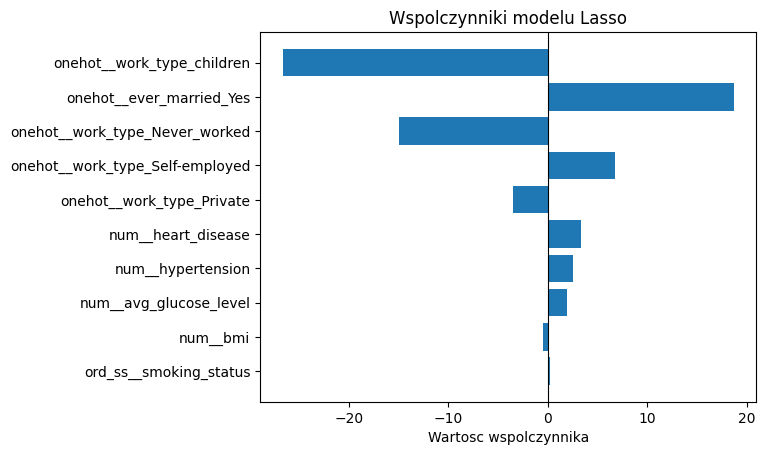

In [19]:
#jako ze to pipeline trzeba troche sie do tego dobrac

feature_names = chosen_model.named_steps['preprocessor'].get_feature_names_out()
coeffs = chosen_model.named_steps['model'].coef_

importances = pd.DataFrame({
    'feature_names': feature_names,
    'importances': coeffs
}).sort_values(by='importances', ascending=True, key=abs)

plt.barh(y=importances['feature_names'], width=importances['importances'])
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Wspolczynniki modelu Lasso")
plt.xlabel("Wartosc wspolczynnika")
plt.show()

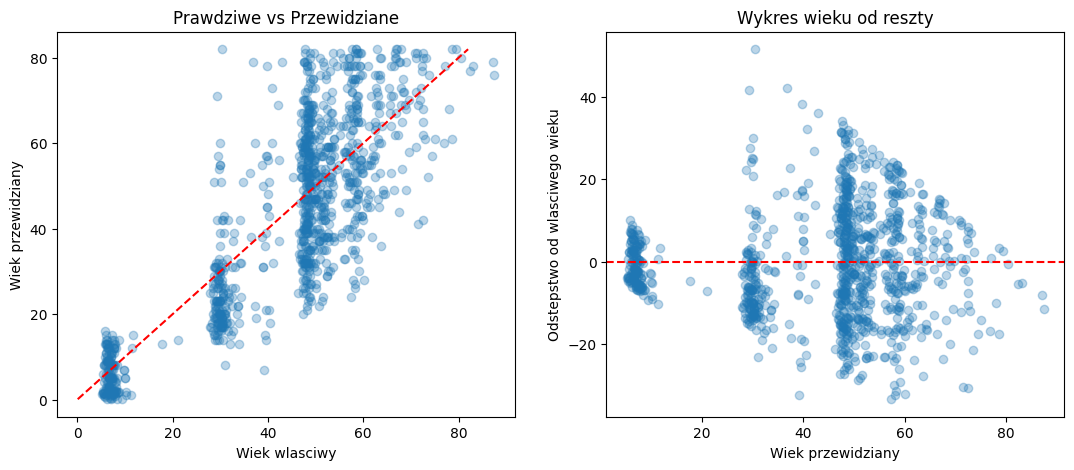

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

axes[0].scatter(y_pred, y_test, alpha = 0.3)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Wiek wlasciwy')
axes[0].set_ylabel('Wiek przewidziany')
axes[0].set_title("Prawdziwe vs Przewidziane")

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3)
axes[1].axhline(0, color = 'red', linestyle = '--')
axes[1].set_xlabel('Wiek przewidziany')
axes[1].set_ylabel('Odstepstwo od wlasciwego wieku')
axes[1].set_title('Wykres wieku od reszty')

plt.show()

Powyzsze wykresu pokazuja jak poradzil sobie model z przewidywaniem wieku. <br>
Wyrazne lejki na wykresie po lewo mowia o dosc ciekawej zaleznosci. Model dla poszczegolnych pacjentow o podobnych cechach (bo duzo jest parametrow binarnych) przewidywal ten sam wiek. Jesli pacjent A i pacjent B mieli takie same albo bardzo zblizone wartosci glukozy, bmi oraz byli zatrudnieni w sektorze prywatnym oraz posiadali zone i dwojke dzieci to pomimo roznicy w ich wieku (np. 40 i 60 lat) model przypisywal im ten sam wiek (np. 55). Jest to zjawisko ktorego na aktualnych danych nie da sie do konca wyzbyc ze wzgledu na ich wczesniej wspomniana strukture (zero jedynkowa glownie). <br>
Wykres po prawo zas pokazuje jak bardzo model pomylil sie z okresleniem wlasciwego wieku (a raczej o ile). <br>
Najgorzej poradzil sobie w przedziale wiekowym od 45 do 55 lat i to wlasnie ze wzgledu na zaleznosc opisana powyzej. Im bardziej w prawo (wzrost wieku) tym model lepiej przewidzial wiek pacjenta (osoby starsze posiadaja dosc ujednolicone cechy dzieki ktorych regresja przebiegla dosc poprawnie). <br>
Pomimo wyniku 0.68 metryki R^2 dla modelu Lasso uwazam ze na posiadanych danych jest to dosc dobry wynik i model sam w sobie mozna zaklasyfikowac gdzies na pograniczu<br>
zadowalajacy/dobry. <br>
Bez posiadania wiekszej ilosci ciaglych danych nie jest mozliwa dokladniejsza regresja. 